In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd
import pygmt

In [2]:
dls = pd.read_csv('..\\..\\created_data\\botlowsed.csv', sep=',', header=None, 
                 names=['long', 'lat', 'z'], skiprows=1)
print(dls.head())

dms = pd.read_csv('..\\..\\created_data\\botmidsed.csv', sep=',', header=None, 
                 names=['long', 'lat', 'z'], skiprows=1)
print(dms.head())

dus = pd.read_csv('..\\..\\created_data\\botupsed.csv', sep=',', header=None, 
                 names=['long', 'lat', 'z'], skiprows=1)
print(dus.head())

dl = pd.read_csv('..\\..\\created_data\\botlowcru.csv', sep=',', header=None, 
                 names=['long', 'lat', 'z'], skiprows=1)
print(dl.head())

dm = pd.read_csv('..\\..\\created_data\\botmidcru.csv', sep=',', header=None, 
                 names=['long', 'lat', 'z'], skiprows=1)
print(dm.head())

du = pd.read_csv('..\\..\\created_data\\botupcru.csv', sep=',', header=None, 
                 names=['long', 'lat', 'z'], skiprows=1)
print(du.head())

    long   lat     z
0 -133.0  38.0 -5.08
1 -133.0  39.0 -4.95
2 -133.0  40.0 -4.73
3 -133.0  41.0 -3.91
4 -133.0  42.0 -3.84
    long   lat     z
0 -133.0  38.0 -5.08
1 -133.0  39.0 -4.95
2 -133.0  40.0 -4.73
3 -133.0  41.0 -3.91
4 -133.0  42.0 -3.84
    long   lat     z
0 -133.0  38.0 -5.08
1 -133.0  39.0 -4.95
2 -133.0  40.0 -4.73
3 -133.0  41.0 -3.91
4 -133.0  42.0 -3.84
    long   lat      z
0 -133.0  38.0 -11.97
1 -133.0  39.0 -11.81
2 -133.0  40.0 -11.56
3 -133.0  41.0 -10.82
4 -133.0  42.0 -10.75
    long   lat     z
0 -133.0  38.0 -7.28
1 -133.0  39.0 -7.15
2 -133.0  40.0 -6.92
3 -133.0  41.0 -6.12
4 -133.0  42.0 -6.05
    long   lat     z
0 -133.0  38.0 -5.76
1 -133.0  39.0 -5.64
2 -133.0  40.0 -5.41
3 -133.0  41.0 -4.60
4 -133.0  42.0 -4.53


making a dictionary of each latitude with its corrsp long and z

*for lat in df['lat'].unique()* get all the unique lat values to loop through each one once

*blc[lat] = df[df['lat'] == lat][['long','z']]* filters the dataframe to only rows where lat equals the current lat value (38 = 38) and then keeps only long and z

In [3]:
bls = {}
for lat in dls['lat'].unique():
    bls[lat] = dls[dls['lat'] == lat][['long','z']] 

bms= {}
for lat in dms['lat'].unique(): 
    bms[lat] = dms[dms['lat'] == lat][['long','z']] 

bus = {}
for lat in dus['lat'].unique():   
    bus[lat] = dus[dus['lat'] == lat][['long','z']]  

blc = {}
for lat in dl['lat'].unique():
    blc[lat] = dl[dl['lat'] == lat][['long','z']] 

bmc= {}
for lat in dm['lat'].unique(): 
    bmc[lat] = dm[dm['lat'] == lat][['long','z']] 

buc = {}
for lat in du['lat'].unique():   
    buc[lat] = du[du['lat'] == lat][['long','z']]  

now creating a new dataframe (all) made of the long, and then each z for that long at that lat

In [4]:
all = {}
for lat in bls.keys():
    all[lat]=pd.DataFrame({  # creating a new dataframe
        'long':bls[lat]['long'].values,  # grabs the longitude values for that lat
        'z_lows':bls[lat]['z'].values,  # grabbing z and so forth
        'z_mids':bms[lat]['z'].values,
        'z_ups':bus[lat]['z'].values,
        'z_lowc':blc[lat]['z'].values, 
        'z_midc':bmc[lat]['z'].values,
        'z_upc':buc[lat]['z'].values})    
    
print(f'latitude 41: {all[41]}')

latitude 41:      long  z_lows  z_mids  z_ups     z_lowc     z_midc  z_upc
0  -133.0   -3.91   -3.91  -3.91 -10.820000  -6.120000  -4.60
1  -132.0   -3.94   -3.94  -3.94 -10.900000  -6.160000  -4.63
2  -131.0   -3.85   -3.85  -3.85 -10.740000  -6.060000  -4.54
3  -130.0   -3.79   -3.79  -3.79 -10.590000  -5.960000  -4.47
4  -129.0   -3.71   -3.71  -3.71 -10.500000  -5.880000  -4.39
5  -128.0   -3.84   -3.84  -3.84 -10.000000  -5.810000  -4.46
6  -127.0   -3.78   -3.78  -3.78  -9.800000  -5.710000  -4.38
7  -126.0   -3.88   -3.88  -3.88  -9.500000  -5.680000  -4.44
8  -125.0   -3.37   -3.37  -3.37  -9.800000  -5.420000  -4.01
9  -124.0   -3.61   -3.61  -2.61 -27.740000 -15.670000  -8.43
10 -123.0    0.67    0.67   0.67 -29.379999 -23.070000 -11.95
11 -122.0    0.11    0.11   0.11 -32.500000 -25.650000 -13.58
12 -121.0    1.38    1.38   1.38 -35.509998 -22.959999 -10.79
13 -120.0    1.52    1.52   1.52 -35.380001 -22.830000 -10.65
14 -119.0    1.36    1.36   1.36 -28.360001 -18.260000  -

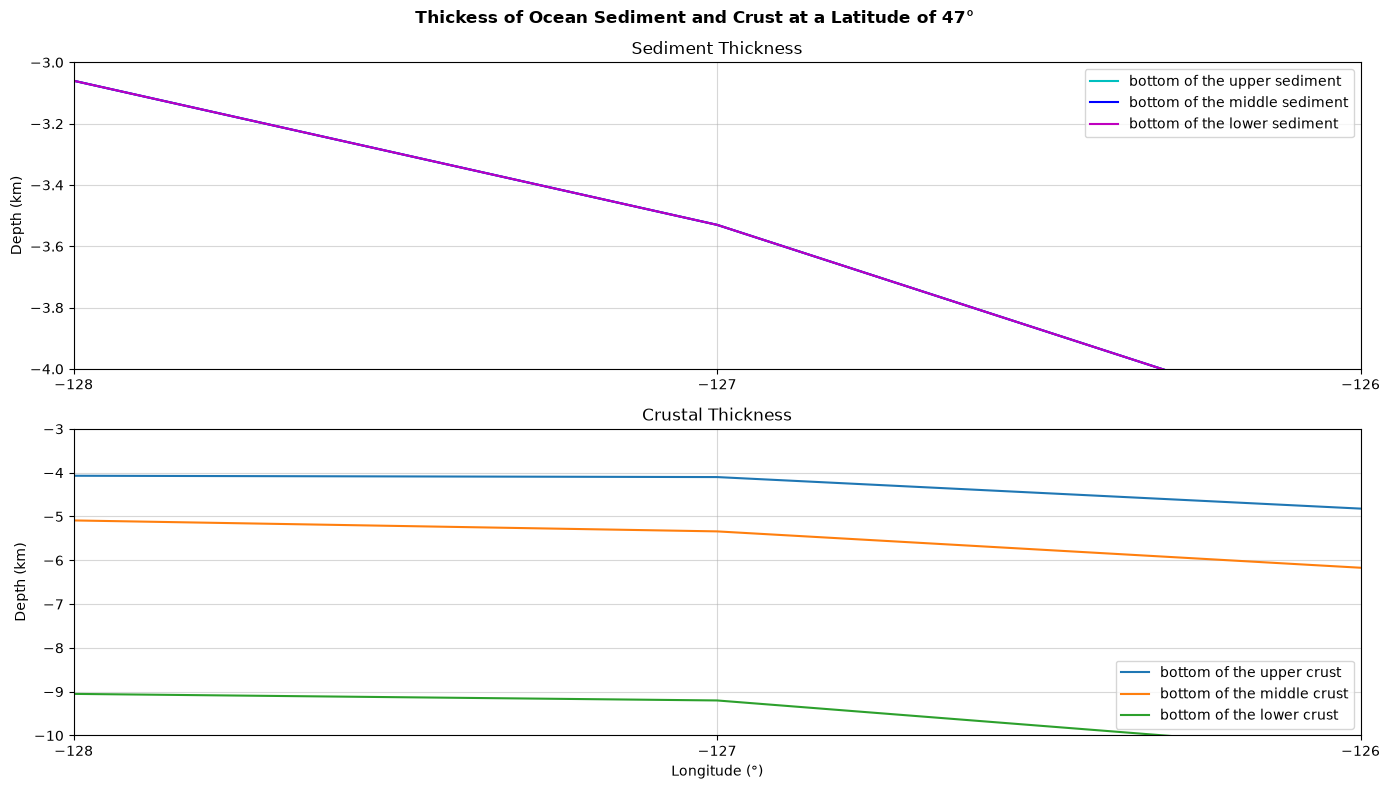

In [ ]:
lat = 47

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(14, 8))

ax0.plot(all[lat]['long'], all[lat]['z_ups'], label='bottom of the upper sediment', c='c')
ax0.plot(all[lat]['long'], all[lat]['z_mids'], label='bottom of the middle sediment', c='b')
ax0.plot(all[lat]['long'], all[lat]['z_lows'], label='bottom of the lower sediment', c='m')
ax1.plot(all[lat]['long'], all[lat]['z_upc'], label='bottom of the upper crust')
ax1.plot(all[lat]['long'], all[lat]['z_midc'], label='bottom of the middle crust')
ax1.plot(all[lat]['long'], all[lat]['z_lowc'], label='bottom of the lower crust')

# ax0.set_xlabel('Longitude')
ax0.set_ylabel('Depth (km)')
ax0.set_title('Sediment Thickness')
# ax0.set_ylim(-4, -3)
# ax0.set_xlim(-128, -126)
ax0.legend()
ax0.xaxis.set_major_locator(plt.MultipleLocator(1)), ax0.grid(alpha=0.5)

ax1.set_xlabel('Longitude (°)')
ax1.set_ylabel('Depth (km)')
# ax1.set_ylim(np.min(all[lat]['z_lowc'] - 5), 0)
# ax1.set_ylim(-10, -3)
# ax1.set_xlim(-128, -126)
ax1.set_title('Crustal Thickness')
ax1.legend()
ax1.xaxis.set_major_locator(plt.MultipleLocator(1)), ax1.grid(alpha=0.5)

fig.suptitle(f'Thickess of Ocean Sediment and Crust at a Latitude of {lat}°', fontweight='bold')
plt.tight_layout()

fig.savefig(f"..\\..\\figures\\crust_thickness\\{lat}_latitude.png", dpi=400)

plt.show()

In [34]:
filtered = {}  # for values with sufficient sediment cover (greater than 200m)
for lat in all.keys():
    diff = all[lat]['z_ups'] - all[lat]['z_lows']
    filtered[lat] = all[lat][diff >= 0.2]

removed = {}
for lat in all.keys():
    diff = all[lat]['z_ups'] - all[lat]['z_lows']
    removed[lat] = all[lat][diff < 0.2]

for lat in all.keys():
    original = len(all[lat])
    kept = len(filtered[lat])
    print(f'lat {lat}: {original} rows -> {kept} rows ({original - kept} removed)')


lat 38.0: 15 rows -> 2 rows (13 removed)
lat 39.0: 15 rows -> 1 rows (14 removed)
lat 40.0: 15 rows -> 1 rows (14 removed)
lat 41.0: 15 rows -> 1 rows (14 removed)
lat 42.0: 15 rows -> 0 rows (15 removed)
lat 43.0: 15 rows -> 0 rows (15 removed)
lat 44.0: 15 rows -> 1 rows (14 removed)
lat 45.0: 15 rows -> 1 rows (14 removed)
lat 46.0: 15 rows -> 0 rows (15 removed)
lat 47.0: 15 rows -> 0 rows (15 removed)
lat 48.0: 15 rows -> 2 rows (13 removed)
lat 49.0: 15 rows -> 2 rows (13 removed)
lat 50.0: 15 rows -> 0 rows (15 removed)
lat 51.0: 15 rows -> 0 rows (15 removed)
lat 52.0: 15 rows -> 1 rows (14 removed)
lat 53.0: 15 rows -> 1 rows (14 removed)
lat 54.0: 15 rows -> 1 rows (14 removed)


In [95]:
# combine all lats into one dataframe and export
df_export = pd.concat(filtered.values(), keys=filtered.keys()).reset_index(level=0).rename(columns={'level_0': 'lat'})
df_export.to_csv("..\\..\\created_data\\filtered_0.2.csv", index=False)